In [12]:
import os
import warnings
warnings.filterwarnings('ignore')
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'


import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.regularizers import l2 #to wazne
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import preprocessing as p
from sklearn.model_selection import train_test_split

import tensorflow as tf
import pandas as pd
from tensorflow.keras.datasets import mnist
from sklearn import preprocessing as p
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

df = pd.read_csv('/usr/share/SI/alzheimers_disease_data.csv')

y = df['Diagnosis']
X = df.drop(['Diagnosis','DoctorInCharge', 'PatientID'], axis = 1)

data_ss = p.StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(data_ss, y, test_size= 0.2, random_state=42)

# Wczytaj zbiór "/usr/share/SI/lending_club_loan_dataset.csv" i znormalizuj dane (jak na poprzednich zajęciach)
# Stwórz dwa modele. Każdy z nich powinien mieć jedną warstwę ukrytą o 256 neuronach. 
# Różnica polega na dołączeniu w jednym z nich warstwy Dropout zaraz po 
# warstwie ukrytej - Dropout(0.2).
# Wytrenuj oba modele
# Stórz wykresy porównujące val_acc i acc obu modeli

In [13]:
#metoda do zapobiegania przetrenowaniu sieci - tak samo regularyzacja
#chcemy wprowadzic nowe zachowania ktore zapobiegaja
#dropout to warstwa sieci neuronowej ktora wprowadzamy i ona wylacza losowo okreslony % sieci
#bardziej skrajna metoda, lepiej dziala na duzych zbiorach danych
#duza interwencja, neurony moga stracic informacje
#generalnie unika sie dropoutu, to taka ostatecznosc gdy siec ma duzo przypadkow i sobie z nimi nie radzi
#odbieramy stabilnosc, musi bazowac na sumie neuronow


In [14]:
model1 = Sequential([
    Input(shape=(32,)), #liczba kolumn
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model1.compile(loss="binary_crossentropy", optimizer = "adam", metrics=['accuracy'])
history1 = model1.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test))

Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6556 - loss: 0.6438 - val_accuracy: 0.7209 - val_loss: 0.5596
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7522 - loss: 0.5267 - val_accuracy: 0.7698 - val_loss: 0.4906
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7935 - loss: 0.4692 - val_accuracy: 0.7977 - val_loss: 0.4475
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8220 - loss: 0.4315 - val_accuracy: 0.8140 - val_loss: 0.4263
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8284 - loss: 0.4033 - val_accuracy: 0.8140 - val_loss: 0.4138
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8412 - loss: 0.3815 - val_accuracy: 0.8116 - val_loss: 0.4060
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8610 - loss: 0.3641 - val_accuracy: 0.8023 - val_loss: 0.4004
Epoch 8/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8517 - loss: 0.3630 - val_accuracy: 0.8093 - v

In [15]:
model2 = Sequential([
    Input(shape=(32,)), #liczba kolumn
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model2.compile(loss="binary_crossentropy", optimizer = "adam", metrics=['accuracy'])
history2 = model2.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test))

Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6126 - loss: 0.6615 - val_accuracy: 0.7093 - val_loss: 0.5660
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7574 - loss: 0.5276 - val_accuracy: 0.7814 - val_loss: 0.4840
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8115 - loss: 0.4550 - val_accuracy: 0.8000 - val_loss: 0.4399
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8371 - loss: 0.4120 - val_accuracy: 0.8233 - val_loss: 0.4153
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8435 - loss: 0.3842 - val_accuracy: 0.8256 - val_loss: 0.4035
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8464 - loss: 0.3665 - val_accuracy: 0.8279 - val_loss: 0.3981
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8470 - loss: 0.3546 - val_accuracy: 0.8256 - val_loss: 0.3945
Epoch 8/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8563 - loss: 0.3427 - val_accuracy: 0.8349 - v

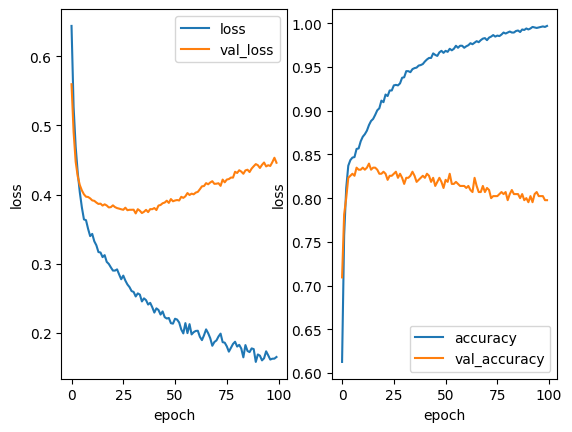

In [17]:
hist = pd.DataFrame(history1.history)
hist2 = pd.DataFrame(history2.history)

plt.subplot(1,2,1)
plt.plot(hist.loss, label = "loss")
plt.plot(hist.val_loss, label = "val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist2.accuracy, label = "accuracy")
plt.plot(hist2.val_accuracy, label = "val_accuracy")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

In [ ]:
#val los exploduje!!!! a los spada do 0
#acc w testowych (val, pomaranczka) moze osiagnac 1, a w val powoli spada z 0.8
#model z dropoutem sie przetrenowuje bo absurdalne warunki ale wzrost jest o wiele mniejszy - blokowanie